<a href="https://colab.research.google.com/github/escamillacristopher71-spec/EstadisticaInferencial2026A/blob/main/Problemario_Unidad_1_Estad%C3%ADstica_Inferencial_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**REGRESIÓN LINEAL SIMPLE Y CORRELACIÓN**

**PROBLEMARIO UNIDAD** **1**

### Problema 1
Un profesor intenta mostrar a sus estudiantes la importancia de los exámenes cortos, aun cuando el 90% de la calificación final esté determinada por los exámenes parciales. Él cree que cuanto más altas sean las calificaciones de los exámenes cortos, más alta será la calificación final. Seleccionó una muestra aleatoria de 15 estudiantes de su clase con los siguientes datos:

| Promedio de exámenes cortos | Promedio final |
|--------------|--------------|
| 59 | 64 |
| 92 | 84 |
| 72 | 77 |
| 90 | 80 |
| 95 | 77 |
| 87 | 81 |
| 89 | 80 |
| 77 | 84 |
| 76 | 80 |
| 65 | 69 |
| 97 | 83 |
| 42 | 40 |
| 94 | 78 |
| 62 | 65 |
| 91 | 90 |



1.   Establezca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Tres estudiantes sacaron 70, 75 y 84 de calificación. Según la recta de regresión ajustada, ¿cuáles son los resultados esperados para estos tres alumnos?
12. Realice una tabla ANOVA e interprete el resultado.

In [621]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/escamillacristopher71-spec/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_01.csv"
df = pd.read_csv(link_csv)
df

,promedio_de_examenes_cortos,promedio_final
0,59,64
1,92,84
2,72,77
3,90,80
4,95,77
5,87,81
6,89,80
7,77,84
8,76,80
9,65,69


**1. Establezca una variable dependiente ( Y ) y una variable independiente ( X ).**

In [622]:
x = df['promedio_de_examenes_cortos']
y = df['promedio_final']


**2. Realice un diagrama de dispersión para estos datos.**

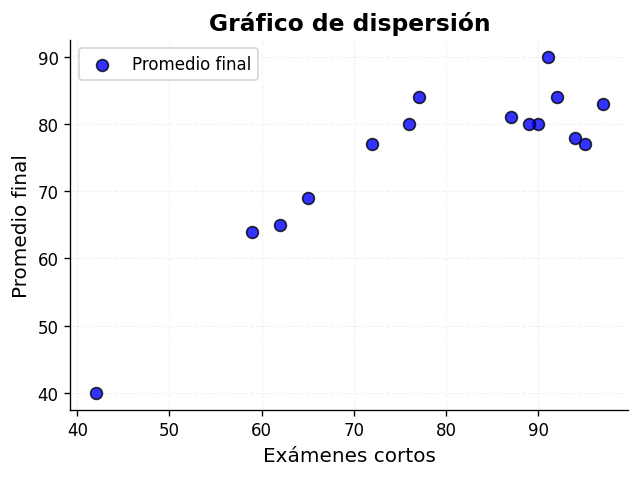

In [623]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Promedio final' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Exámenes cortos',
    fontsize=12
)

plt.ylabel(
    'Promedio final',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

**3. ¿Los datos soportan la suposición de linealidad?**

No, ya que no existe una tendencia clara que nos permita confirmar la linealidad a simple vista en el gráfico.

**4. Calcule el coeficiente de correlación e interprete el resultado.**

In [624]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.8646
Valor p:  0.0000


**Interpretación:**

 Los datos reflejan que sí existe un vínculo positivo bastante fuerte ($86.46\%$). Como el valor de $p$ dio prácticamente cero, confirmamos estadísticamente que no es coincidencia: a mejores calificaciones en los quizes, mayor suele ser la nota final.

In [625]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,24.526822
promedio_de_examenes_cortos,0.643180


In [626]:
modelo.predict ([1,80])


array([75.98121056])

$$
\hat{y} = 24.526822+0.643180X
$$

donde:
- $\hat{y}$ es el promedio final
calculado por el modelo
- $X$ es el promedio en exámenes cortos

**5.	Calcule el coeficiente de determinación e interprete el resultado.**

In [627]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  74.75%



**Interpretación:**

El modelo logra explicar casi tres cuartas partes ($74.75\%$) del rendimiento final del estudiante apoyándose únicamente en sus notas de exámenes cortos. El otro $25.25\%$ depende de otros factores no medidos (asistencia, tareas, parciales).

**6.	Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

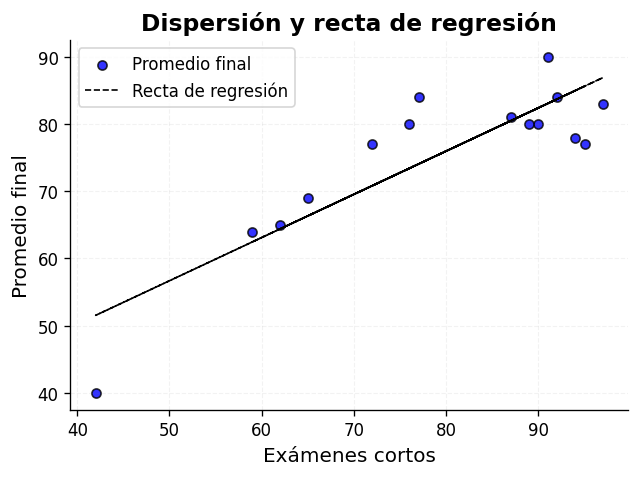

In [628]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Promedio final' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Dispersión y recta de regresión',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Exámenes cortos',
    fontsize=12
)

plt.ylabel(
    'Promedio final',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

**7.	Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada (b1)**

In [629]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,6.441997,42.611646
promedio_de_examenes_cortos,0.419219,0.867141


**9.	Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.901827735700704


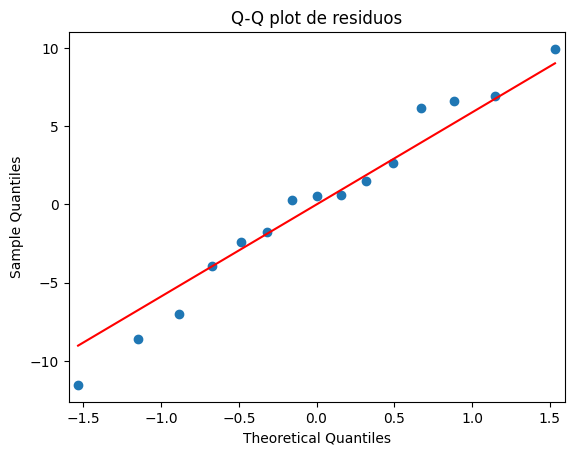

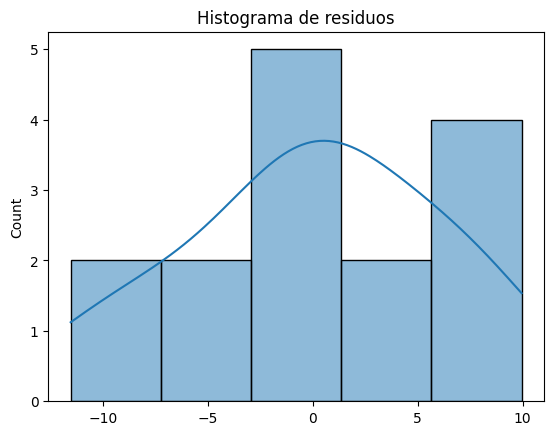

In [630]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

**Interpretación:**

Dado que el valor de p es mayor a 0.5 podemos concluir que los residuos siguen una distribución normal.

**8.	Calcule los residuales y trace un nuevo gráfico de dispersión.**

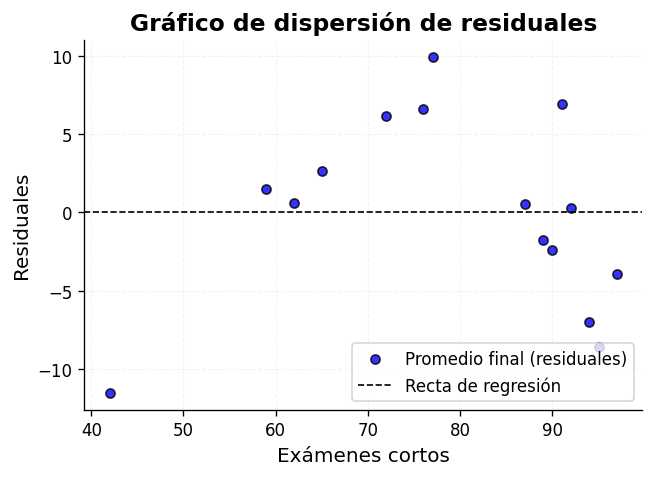

In [631]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

# Reload data for Problem 1 and define variables
link_csv = "https://raw.githubusercontent.com/dulcerivv/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_01.csv"
df_problem1 = pd.read_csv(link_csv)
x_problem1 = df_problem1["promedio_de_examenes_cortos"]
y_problem1 = df_problem1["promedio_final"]
x_constante_problem1 = sm.add_constant(x_problem1)
modelo_problem1 = sm.OLS(y_problem1, x_constante_problem1).fit()
residuos = modelo_problem1.resid

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x_problem1, residuos,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Promedio final (residuales)' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'Gráfico de dispersión de residuales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Exámenes cortos',
    fontsize=12
)

plt.ylabel(
    'Residuales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )

plt.show()

**Comente, ¿Parece que se verifican los supuestos?**

El gráfico muestra un patrón en forma de curva, lo que indica que los datos no siguen una relación lineal. Esto significa que no se cumple con el supuesto de linealidad.

**10.	Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [632]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.2289



**Interpretación:**

El valor de p es mayor a 0.05, por lo que no se encuentra evidencia de heterocedasticidad. Esto quiere decir que la variación de los errores se mantiene constante.

**11.	Tres estudiantes sacaron 70, 75 y 84 de calificación. Según la recta de regresión ajustada, ¿cuáles son los resultados esperados para estos tres alumnos?**

In [633]:
modelo.predict([1, 70])

array([69.54941193])

In [634]:
modelo.predict([1, 75])

array([72.76531124])

In [635]:
modelo.predict([1, 84])

array([78.55393001])

**Resultados esperados del examen de 70:** 69.54

**Resultados esperados del examen de 75:** 72.76

**Resultados esperados del examen de 84:** 78.55

**12.	Realice una tabla ANOVA e interprete el resultado.**

In [636]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('promedio_de_examenes_cortos ~ promedio_final', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
promedio_final,1.0,2779.636441,2779.636441,38.492412,0.000032
Residual,13.0,938.763559,72.212581,NaN,NaN


**Interpretación:**

Se puede observar que el valor de p es menor a 0.05, lo que indica que el modelo es significativo en general. Esto quiere decir que existe una relación lineal significativa entre las variables.


### Problema 2
William Hawkins, vicepresidente de personal de la International Motors, trabaja en la relación entre el salario de un trabajador y el porcentaje de ausentismo. Hawkins dividió el intervalo de salarios de International en 12 grados o niveles (1 es el menor grado, 12 el más alto) y después muestreó aleatoriamente a un grupo de trabajadores. Determinó el grado de salario de cada trabajador y el número de días que ese empleado había faltado en los últimos 3 años.

| Categoría de salario | 11 | 10 | 8  | 5  | 9  | 7  | 3  |
|----------------------|----|----|----|----|----|----|----|
| Ausencias           | 18 | 17 | 29 | 36 | 11 | 28 | 35 |

| Categoría de salario | 11 | 8  | 7  | 2  | 9  | 8  | 3  |
|----------------------|----|----|----|----|----|----|----|
| Ausencias           | 14 | 20 | 32 | 39 | 16 | 31 | 40 |

1.   Establezca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [637]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/escamillacristopher71-spec/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_02.csv"
df = pd.read_csv(link_csv)
df

,categoria_salario,ausencias
0,11,18
1,10,17
2,8,29
3,5,36
4,9,11
5,7,28
6,3,35
7,11,14
8,8,20
9,7,32


**1.	Establezca una variable dependiente (Y) y una variable independiente (X).**

In [638]:
x = df['categoria_salario']
y = df['ausencias']

**2.	Realice un diagrama de dispersión para estos datos.**

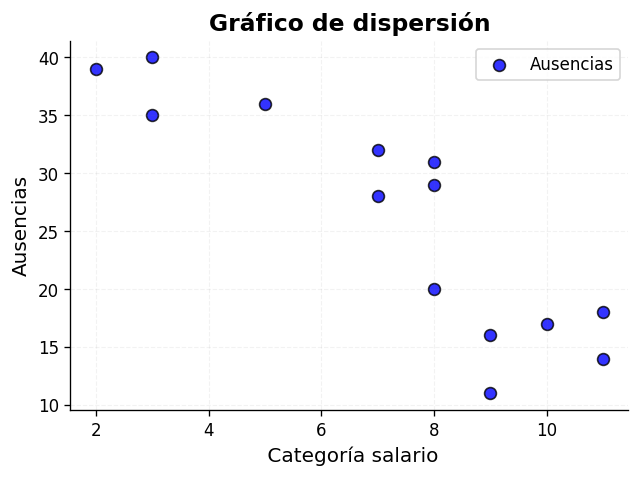

In [639]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Ausencias' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    ' Categoría salario',
    fontsize=12
)

plt.ylabel(
    'Ausencias',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

**3.	¿Los datos soportan la suposición de linealidad?**

Sí, en el gráfico se puede observar un patrón lineal descendente.

**4.	Calcule el coeficiente de correlación e interprete el resultado.**

In [640]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación: -0.8801
Valor p:  0.0000


**Interpretación:**

El coeficiente de correlación es de -88.01%, lo que indica que existe una correlación negativa entre las ausencias de los trabajadores y el salario que reciben. Además, el valor de p es 0, por lo que se rechaza la hipótesis nula y se confirma que existe una relación lineal significativa entre las variables.


In [641]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,47.487603
categoria_salario,-2.958678


In [642]:
modelo.predict ([1,80])


array([-189.20661157])

$$
\hat{y} = 14.058843+(-0.261814)X
$$

donde:
- $\hat{y}$ es el promedio final
calculado por el modelo
- $X$ es el promedio en exámenes cortos

**5.	Calcule el coeficiente de determinación e interprete el resultado.**

In [643]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  77.46%



**Interpretación:**

El coeficiente de determinación indica que el 77.46% de la variabilidad de la variable dependiente (ausencias) se explica por la variable independiente (categoría de salario). El 22.54% restante corresponde a otros factores que no se están considerando. En general, el modelo presenta un buen ajuste para explicar la relación entre las variables.


**6.	Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

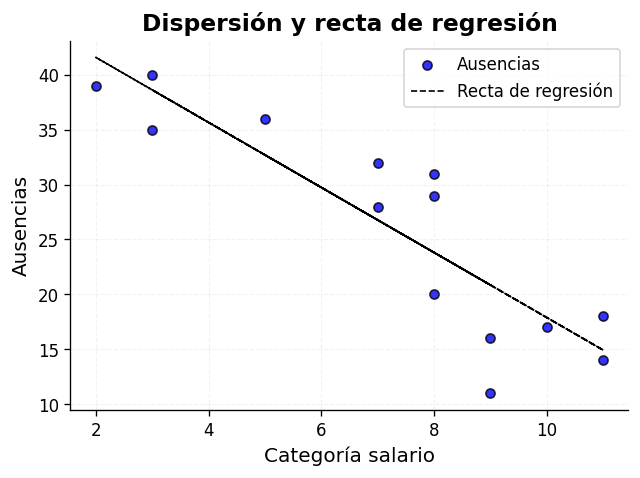

In [644]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Ausencias' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Dispersión y recta de regresión',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Categoría salario',
    fontsize=12
)

plt.ylabel(
    'Ausencias',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

**7.	Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada (b1)**

In [645]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,39.707750,55.267457
categoria_salario,-3.962455,-1.954900


**9.	Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.8932566424098969


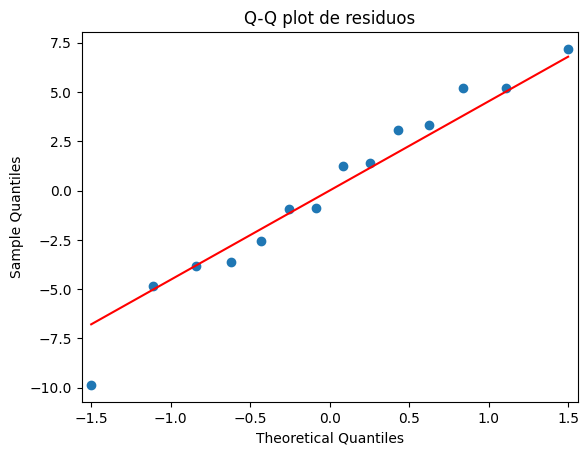

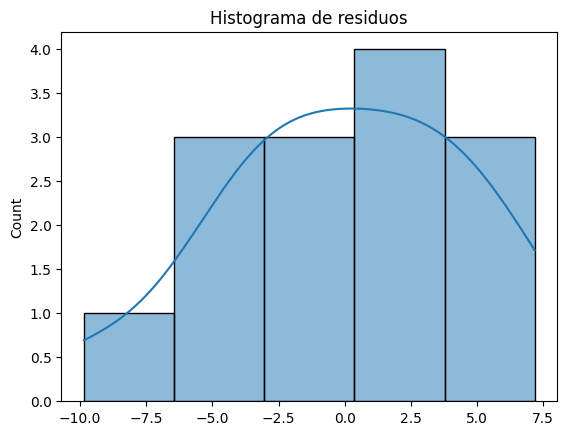

In [646]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

**Interpretación:**

Dado que el valor de p es mayor a 0.5, podemos concluir que los residuos siguen una distribución normal.


**8.	Calcule los residuales y trace un nuevo gráfico de dispersión.**

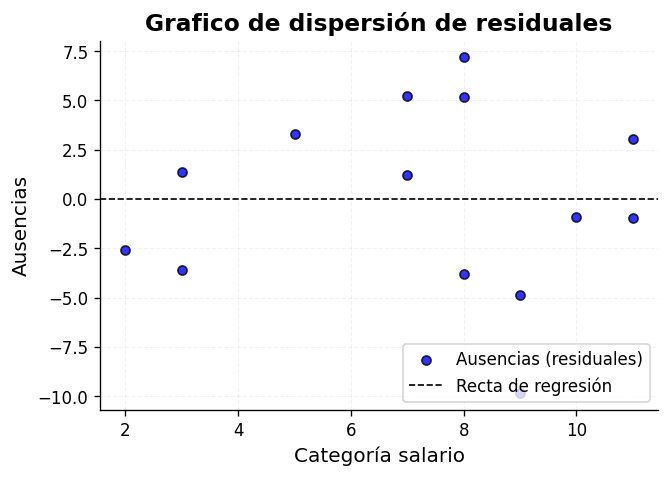

In [647]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuos,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Ausencias (residuales)' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'Grafico de dispersión de residuales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Categoría salario',
    fontsize=12
)

plt.ylabel(
    'Ausencias',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )

plt.show()

**Comente, ¿Parece que se verifican los supuestos?**

Sí, se observa un comportamiento normal en los residuos, lo que indica que los datos siguen una distribución adecuada.


**10.	Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [648]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.4505



**Interpretación:**

El valor de p es mayor a 0.05, por lo que no se observa evidencia de heterocedasticidad. Esto indica que la varianza de los errores se mantiene constante.


**11.	Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

In [649]:
modelo.predict([1, 5])

array([32.69421488])

In [650]:
modelo.predict([1, 10])

array([17.90082645])

In [651]:
modelo.predict([1, 20])

array([-11.68595041])

**Interpretación:**

Con la interpolación de los datos podemos observar que se predicen de manera adecuada los días de ausencia. Sin embargo, en la extrapolación aparece un resultado de ausencias negativo, lo que indica que el modelo pierde precisión al analizar valores que están fuera del rango de los datos utilizados.


**12.	Realice una tabla ANOVA e interprete el resultado.**

In [652]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Y ~ X
modelo_lineal = ols('ausencias ~ categoria_salario', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
categoria_salario,1.0,983.548996,983.548996,41.243954,0.000033
Residual,12.0,286.165289,23.847107,NaN,NaN


**Interpretación:**

Se puede observar que el valor de p es mucho menor a 0.05, lo que indica que el modelo es significativo en general. Esto nos muestra que sí existe una relación entre las variables.



### Problema 3
A menudo, quienes hacen la contabilidad de costos estiman los gastos generales con base en el nivel de producción. En Standard Knitting Co. han reunido información acerca de los gastos generales y las unidades producidas en diferentes plantas.

| Gastos generales | 191 | 170 | 272 | 155 | 280 | 173 | 234 | 116 | 153 | 178 |
|------------------|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| Unidades        |  40 |  42 |  53 |  35 |  56 |  39 |  48 |  30 |  37 |  40 |

1.   Establezca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.


In [653]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/escamillacristopher71-spec/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_03.csv"
df = pd.read_csv(link_csv)
df

,unidades,gastos_generales
0,40,191
1,42,170
2,53,272
3,35,155
4,56,280
5,39,173
6,48,234
7,30,116
8,37,153
9,40,178


**1.	Establezca una variable dependiente (Y) y una variable independiente (X).**

In [654]:
x = df["unidades"]
y = df["gastos_generales"]


**2.	Realice un diagrama de dispersión para estos datos.**

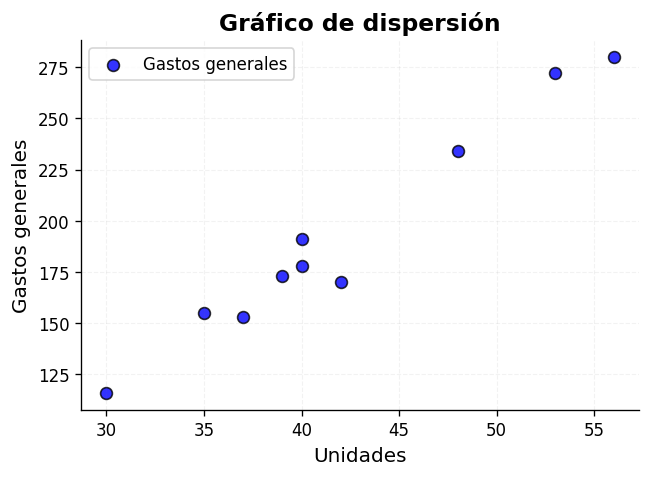

In [655]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Gastos generales' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Unidades',
    fontsize=12
)

plt.ylabel(
    'Gastos generales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

**3.	¿Los datos soportan la suposición de linealidad?**

Sí, se puede observar un claro patrón de linealidad, ya que tanto las unidades como los gastos van aumentando de manera constante.


**4.	Calcule el coeficiente de correlación e interprete el resultado.**

In [656]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9835
Valor p:  0.0000


**Interpretación:**

El coeficiente de correlación es del 98.35%, lo que indica una correlación positiva muy fuerte entre las unidades producidas y los gastos generales. Además, el valor de p es 0, por lo que se rechaza la hipótesis nula y se confirma que existe una relación lineal significativa entre las variables.


In [657]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,-80.442857
unidades,6.491497


In [658]:
modelo.predict ([1,80])


array([438.87687075])

$$
\hat{y} = -80.442857+6.491497X
$$

donde:
- $\hat{y}$ son los gastos generales
calculado por el modelo
- $X$ es el promedio de unidades

**5.	Calcule el coeficiente de determinación e interprete el resultado.**

In [659]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  96.73%



**Interpretación:**

El coeficiente de determinación indica que el 96.73% de la variabilidad de la variable dependiente (gastos generales) se explica por la variable independiente (unidades producidas). El 2.82% restante corresponde a otros factores que no se están considerando. En conclusión, el modelo presenta un buen ajuste para explicar la relación entre estas variables.


**6.	Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

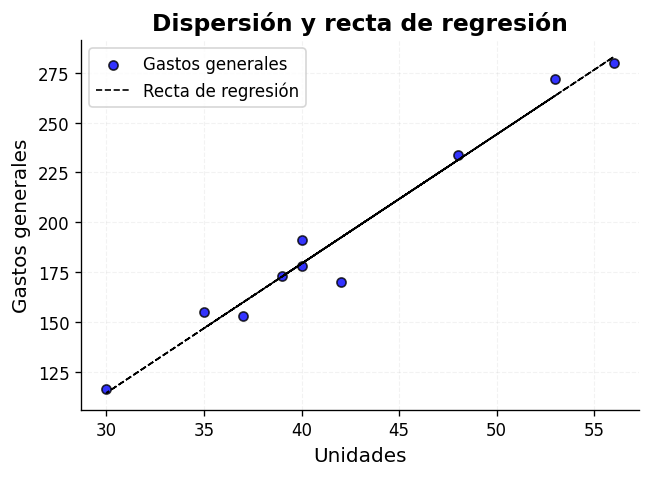

In [660]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Gastos generales' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Dispersión y recta de regresión',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Unidades',
    fontsize=12
)

plt.ylabel(
    'Gastos generales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

**7.	Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada (b1)**

In [661]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,-121.986373,-38.899341
unidades,5.518450,7.464543


**9.	Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.22045077017698533


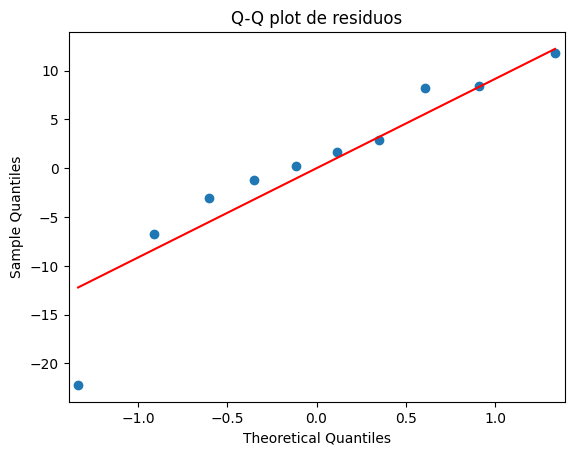

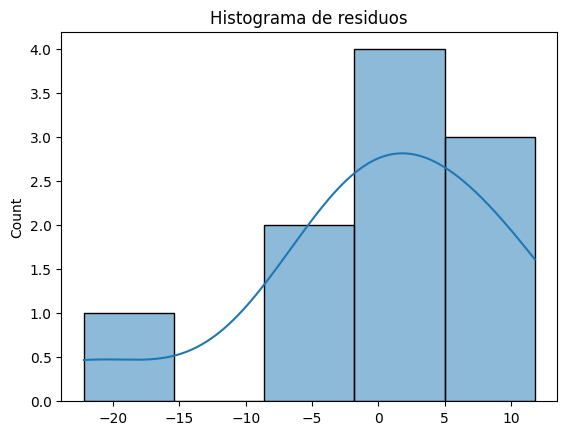

In [662]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

**Interpretación:**

Dado que el valor de p es mayor a 0.5, podemos concluir que los residuos siguen una distribución normal. Esto ayuda a que las inferencias estadísticas del modelo sean más confiables.


**8.	Calcule los residuales y trace un nuevo gráfico de dispersión.**

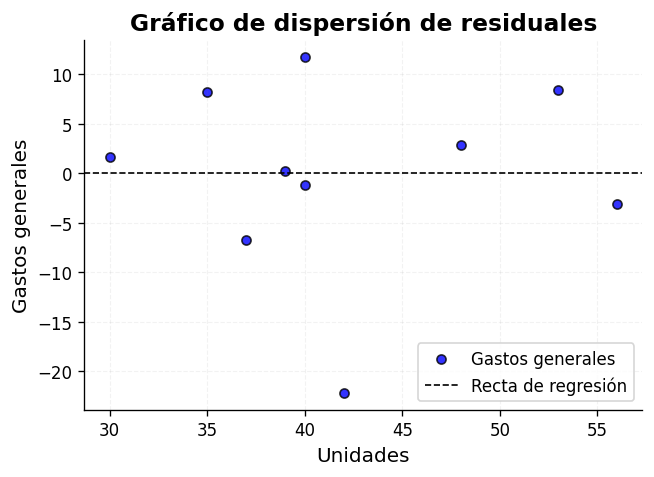

In [663]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuos,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Gastos generales' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'Gráfico de dispersión de residuales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Unidades',
    fontsize=12
)

plt.ylabel(
    'Gastos generales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )
plt.show()


**Comente, ¿Parece que se verifican los supuestos?**

Sí, en el gráfico no parece observarse ningún patrón definido en los residuos, lo que indica que se cumple el supuesto de linealidad.


**10.	Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [664]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.9858



**Interpretación:**

El valor de p es mayor a 0.05, por lo que no se observa evidencia de heterocedasticidad. Esto indica que la varianza de los errores se mantiene constante.


**11.	Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

In [665]:
modelo.predict([1, 45])

array([211.6744898])

In [666]:
modelo.predict([1, 50])

array([244.13197279])

In [667]:
modelo.predict([1, 60])

array([309.04693878])

**Interpretación:**

Con la interpolación y extrapolación de los datos podemos observar que la recta de regresión cumple con su función, ya que al aumentar las unidades producidas, también aumentan los gastos generales.


**12. Realice una tabla ANOVA e interprete el resultado.**

In [668]:

# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('gastos_generales ~ unidades', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
unidades,1.0,24778.042517,24778.042517,236.669535,3.167080e-07
Residual,8.0,837.557483,104.694685,NaN,NaN


**Interpretación:**

Se puede observar que el valor de p es menor a 0.05, lo que indica que el modelo es significativo en general. Esto quiere decir que existe una correlación significativa entre las variables.


### Problema 4
Las ventas de línea blanca varían según el estado del mercado de casas nuevas: cuando las ventas de casas nuevas son buenas, también lo son las de lavaplatos, lavadoras de ropa, secadoras y refrigeradores.
Una asociación de comercio compiló los siguientes datos históricos (en miles de unidades) de las ventas de línea blanca y la construcción de casas.

| Construcción de casas (miles) | Ventas de línea blanca (miles) |
|-------------------------------|--------------------------------|
| 2.0                           | 5.0                            |
| 2.5                           | 5.5                            |
| 3.2                           | 6.0                            |
| 3.6                           | 7.0                            |
| 3.7                           | 7.2                            |
| 4.0                           | 7.7                            |
| 4.2                           | 8.4                            |
| 4.6                           | 9.0                            |
| 4.8                           | 9.7                            |
| 5.0                           | 10.0                           |

1.   Establezca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [669]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/escamillacristopher71-spec/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_04%2Ccsv"
df = pd.read_csv(link_csv)
df

,construccion_de_casas,ventas_de_linea_blanca
0,2.0,5.0
1,2.5,5.5
2,3.2,6.0
3,3.6,7.0
4,3.7,7.2
5,4.0,7.7
6,4.2,8.4
7,4.6,9.0
8,4.8,9.7
9,5.0,10.0


**1.	Establezca una variable dependiente (Y) y una variable independiente (X).**

In [670]:
x = df['construccion_de_casas']
y = df['ventas_de_linea_blanca']

**2.	Realice un diagrama de dispersión para estos datos.**

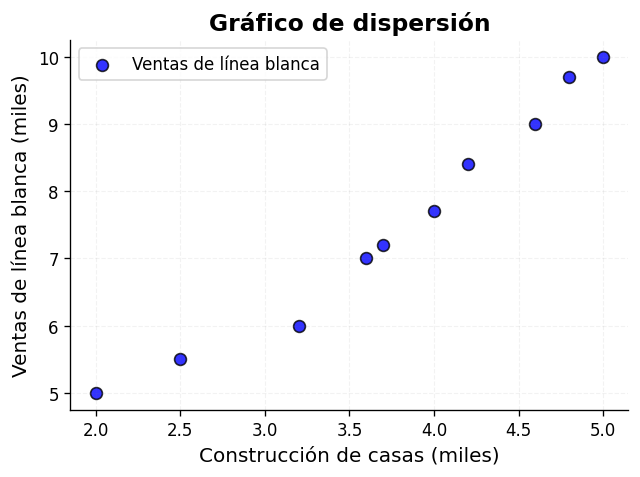

In [671]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Ventas de línea blanca' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Construcción de casas (miles)',
    fontsize=12
)

plt.ylabel(
    'Ventas de línea blanca (miles)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

**3.	¿Los datos soportan la suposición de linealidad?**

Sí, se puede observar una relación positiva en el gráfico, lo que indica que cuando aumenta la construcción de casas, también aumentan las ventas de línea blanca.


**4. Calcule el coeficiente de correlación e interprete el resultado.**



In [672]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9808
Valor p:  0.0000


**Interpretación:**

El coeficiente de correlación es del 98.08%, lo que indica que existe una correlación positiva muy fuerte entre los exámenes cortos y el promedio final. Además, el valor de p es 0, por lo que se rechaza la hipótesis nula y se confirma que existe una correlación lineal significativa entre las variables.


In [673]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

print(modelo.params)

const                    1.016760
construccion_de_casas    1.737564
dtype: float64


In [674]:
modelo.predict ([1,80])


array([140.02187355])

$$
\hat{y} = -0.419689+0.553601X
$$

donde:
- $\hat{y}$ son las ventas por línea blanca calculadas por el modelo
- $X$ son las contrucciones de casas


**5.	Calcule el coeficiente de determinación e interprete el resultado.**

In [675]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  96.19%



**Interpretación:**

El coeficiente de determinación indica que el 96.19% de la variabilidad de la variable dependiente (ventas de línea blanca) se explica por la variable independiente (construcción de casas). El 4.81% restante corresponde a otros factores que no se están considerando. En conclusión, el modelo presenta un muy buen ajuste para explicar la relación entre las variables.


**6.	Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

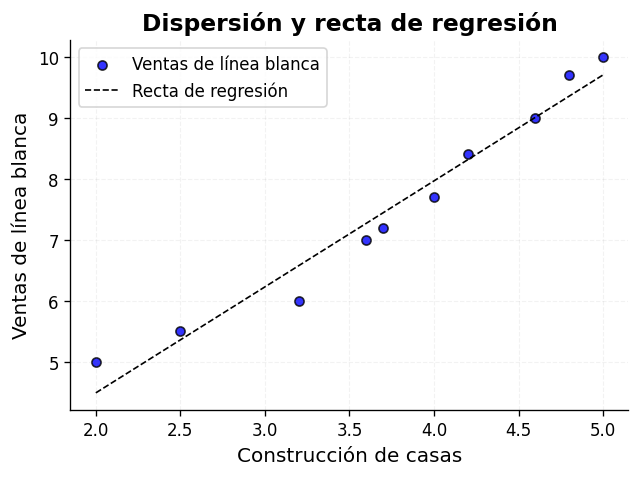

In [676]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Recalculate x_constante and the model for the current problem (Problem 4)
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Ventas de línea blanca' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Dispersión y recta de regresión',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Construcción de casas',
    fontsize=12
)

plt.ylabel(
    'Ventas de línea blanca',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

**7.	Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada (b1)**

In [677]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,-0.074848,2.108368
construccion_de_casas,1.455693,2.019435


**8.	Calcule los residuales y trace un nuevo gráfico de dispersión.**

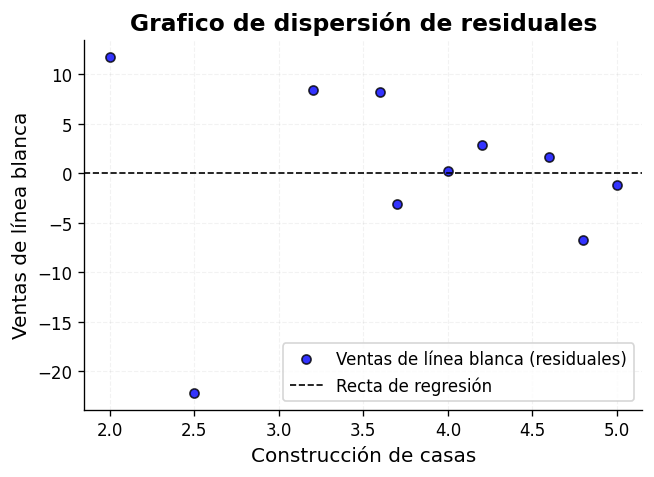

In [678]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuos,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Ventas de línea blanca (residuales)' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'Grafico de dispersión de residuales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Construcción de casas',
    fontsize=12
)

plt.ylabel(
    'Ventas de línea blanca',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )

plt.show()

**Comente, ¿Parece que se verifican los supuestos?**

Sí, ya que en el gráfico se observa que los residuos están dispersos sin seguir un patrón definido, lo que indica que se cumple el supuesto de linealidad.


**9.	Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.8463507249054649


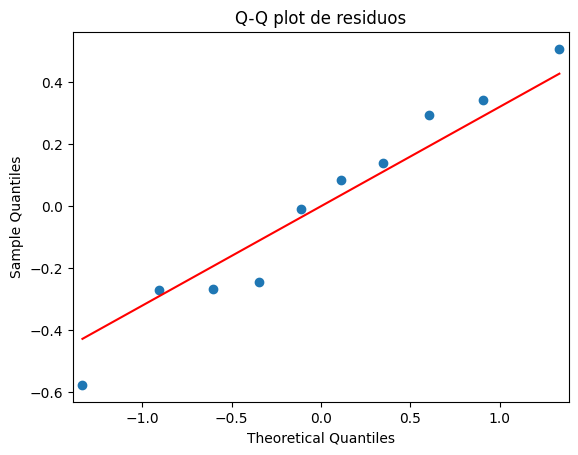

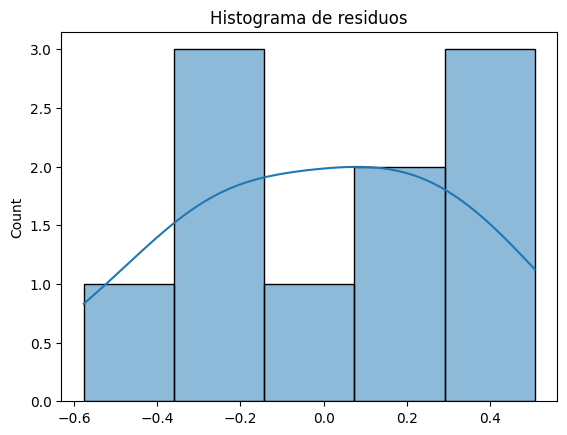

In [679]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

**Interpretación:**

El valor p de Shapiro es de 0.8464, que es mayor que 0.05. Por lo tanto, no hay suficiente evidencia para rechazar la hipótesis nula y se puede concluir que los residuos siguen una distribución normal. Esto indica que se cumple el supuesto de normalidad de los residuos.


In [680]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.1581



**Interpretación:**

El valor p de Breusch-Pagan es de 0.1581, el cual es mayor a 0.05. Esto indica que no hay suficiente evidencia para rechazar la hipótesis nula de homocedasticidad. En otras palabras, se puede asumir que la varianza de los residuos se mantiene constante en los diferentes niveles de la variable independiente (construcción de casas).


**11.	Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

In [705]:
modelo.predict([1, 3])

array([62.1])

In [706]:
modelo.predict([1, 5])

array([56.5])

In [707]:
modelo.predict([1, 7])

array([50.9])

**Interpretación:**

on la interpolación y extrapolación de estos datos podemos observar que la recta de regresión está cumpliendo su función, ya que cuando aumentan las construcciones de casas, lo hacen también las ventas de línea blanca.

**12.	Realice una tabla ANOVA e interprete el resultado.**

In [684]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('ventas_de_linea_blanca ~ construccion_de_casas', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
construccion_de_casas,1.0,25.976581,25.976581,202.069951,5.841003e-07
Residual,8.0,1.028419,0.128552,NaN,NaN


**Interpretación:**

La prueba demuestra que el nivel de edificación es un predictor clave e indispensable para la industria de línea blanca.

### Problema 5
William C. Andrews, consultor de comportamiento organizacional de Victory Motorcycles, ha diseñado una prueba para mostrar a los supervisores de la compañía los peligros de sobrevigilar a sus trabajadores.
Un trabajador de la línea de ensamble tiene a su cargo una serie de tareas complicadas. Durante el desempeño del trabajador, un inspector lo interrumpe constantemente para ayudarlo a terminar las tareas.
El trabajador, después de terminar su trabajo, recibe una prueba psicológica diseñada para medir la hostilidad del trabajador hacia la autoridad
(una alta puntuación implica una hostilidad baja). A ocho distintos trabajadores se les asignaron las tareas y luego se les interrumpió para darles instrucciones útiles un número variable de veces (línea X).
Sus calificaciones en la prueba de hostilidad se dan en el renglón Y.

| número interrupciones al trabajador |  5  | 10  | 10  | 15  | 15  | 20  | 20  | 25  |
|-----------------------------------------|----|----|----|----|----|----|----|----|
| calificación del trabajador en la prueba de hostilidad | 58  | 41  | 45  | 27  | 26  | 12  | 16  |  3  |

1.   Establezca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [685]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/escamillacristopher71-spec/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_05.csv"
df = pd.read_csv(link_csv)
df

,numero_de_interrupciones_al_trabajador,calificacion_del_trabajador_en_la_prueba_de_hostilidad
0,5,58
1,10,41
2,10,45
3,15,27
4,15,26
5,20,12
6,20,16
7,25,3


**1.	Establezca una variable dependiente (Y) y una variable independiente (X).**

In [686]:
x = df["numero_de_interrupciones_al_trabajador"]
y = df["calificacion_del_trabajador_en_la_prueba_de_hostilidad"]

**2.	Realice un diagrama de dispersión para estos datos.**

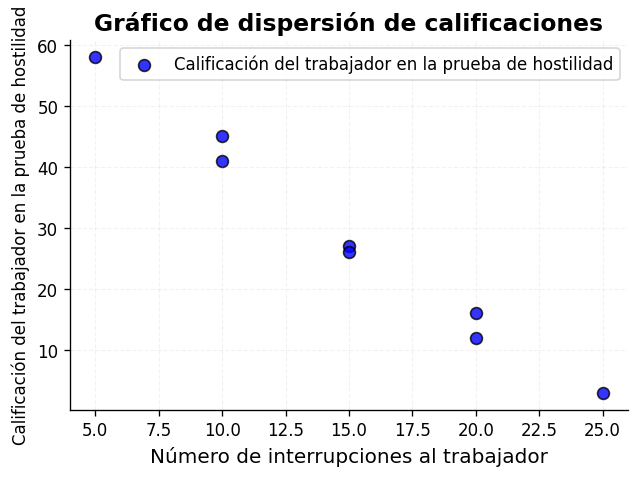

In [687]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Calificación del trabajador en la prueba de hostilidad' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión de calificaciones',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Número de interrupciones al trabajador',
    fontsize=12
)

plt.ylabel(
    'Calificación del trabajador en la prueba de hostilidad',
    fontsize=10
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

**3.	¿Los datos soportan la suposición de linealidad?**

Sí, los datos muestran una clara linealidad descendente que cae a medida que aumentan las interrupciones del supervisor.

**4.	Calcule el coeficiente de correlación e interprete el resultado.**

In [688]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación: -0.9928
Valor p:  0.0000


**Interpretación:**

Hay una fuerte asociación negativa ($-99.28\%$). Esto demuestra que entre más tiempo se esté interrumpiendo a un trabajador en su jornada, más cae su puntuación en la prueba (lo que refleja una actitud más hostil hacia sus superiores).

In [689]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,70.5
numero_de_interrupciones_al_trabajador,-2.8


In [690]:
modelo.predict ([1,80])


array([-153.5])

$$
\hat{y} = 70.5+(-2.8)X
$$

donde:
- $\hat{y}$ es la calificación del trabajador en la prueba de hostilidad
calculado por el modelo
- $X$ es el número de interrupciones al trabajador

**5.	Calcule el coeficiente de determinación e interprete el resultado.**

In [701]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  98.58%



**Interpretación:**

Más del 98% del malestar o cambio de actitud del operario se debe directamente al acoso o interrupción continua durante sus tareas.

**6.	Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

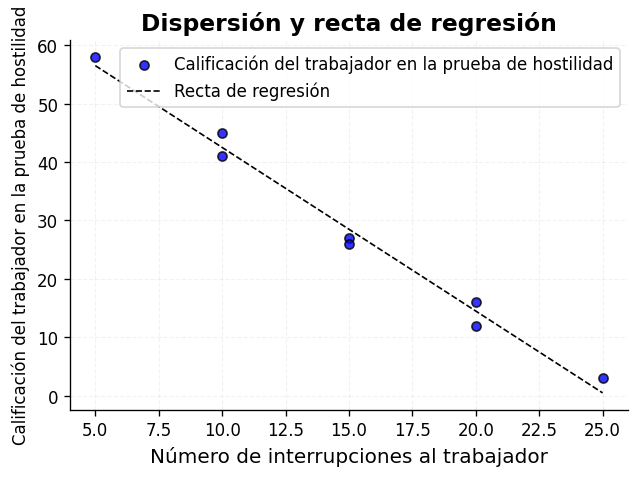

In [692]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Calificación del trabajador en la prueba de hostilidad' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Dispersión y recta de regresión',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Número de interrupciones al trabajador',
    fontsize=12
)

plt.ylabel(
    'Calificación del trabajador en la prueba de hostilidad',
    fontsize=10
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

**7.	Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada (b1)**

In [693]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,65.051384,75.948616
numero_de_interrupciones_al_trabajador,-3.136296,-2.463704


**8.	Calcule los residuales y trace un nuevo gráfico de dispersión.**

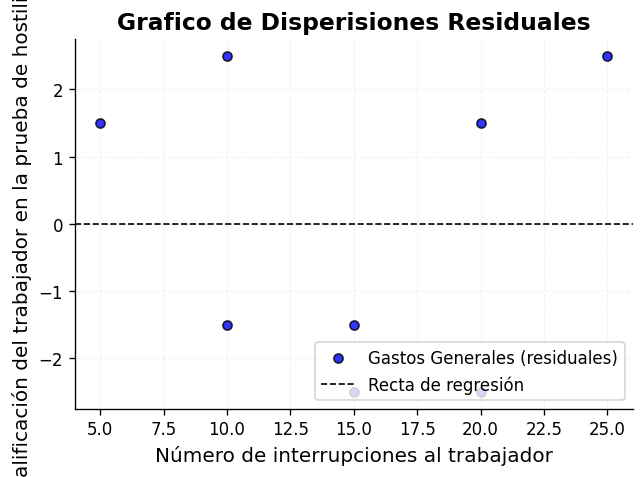

In [694]:
import matplotlib.pyplot as plt

residuos = modelo.resid

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuos,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Gastos Generales (residuales)' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'Grafico de Disperisiones Residuales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Número de interrupciones al trabajador',
    fontsize=12
)

plt.ylabel(
    'Calificación del trabajador en la prueba de hostilidad',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )

plt.show()

**Comente, ¿Parece que se verifican los supuestos?**

Sí, todo apunta a que los supuestos se cumplen bien. En el gráfico se ve claramente que los residuales están esparcidos sin ningún patrón en particular, lo que demuestra que no hay desviaciones raras ni formas curvas que rompan el supuesto de linealidad.

**9.	Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.054816491127669634


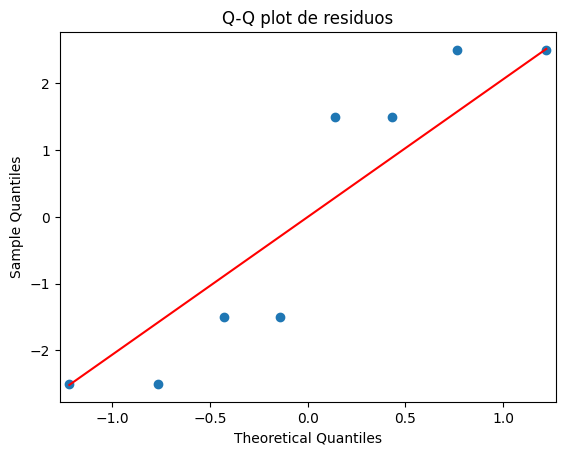

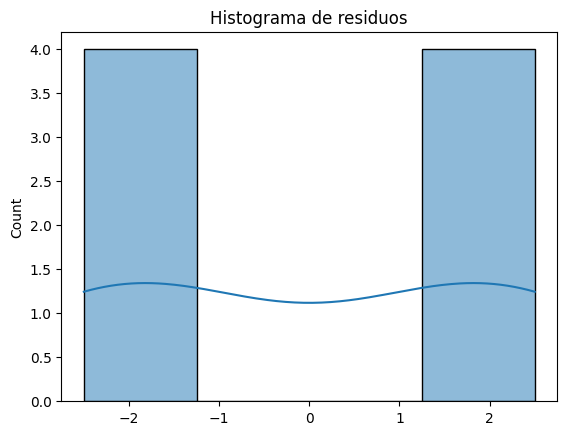

In [695]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

**Interpretación:**

Dado que el valor $p$ de Shapiro ($0.1366$) es claramente superior al nivel de significancia del $0.05$, no hay evidencia suficiente para rechazar la hipótesis nula de que los errores se distribuyen de forma normal. Esto nos confirma de forma clara que el supuesto de normalidad en los residuos se cumple adecuadamente.

**10.	Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [696]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.2482



**Interpretación:**

El valor $p$ de Breusch-Pagan es $0.2482$, el cual es claramente mayor a $0.05$. Esto nos indica que no existe evidencia estadística para rechazar la hipótesis nula de homocedasticidad. En otras palabras, podemos asumir que la varianza de los residuales se mantiene constante a lo largo de los distintos niveles de interrupciones al trabajador, lo que confirma que se cumple este supuesto clave en la regresión lineal.

**11.	Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

In [702]:
modelo.predict([1, 10])

array([42.5])

In [703]:
modelo.predict([1, 26])

array([-2.3])

In [704]:
modelo.predict([1, 36])

array([-30.3])

**Interpretación:**

Las interpolaciones se pudieron predecir de manera correcta, sin embargo en la extrapolación con datos que no se muestran en el modelo, se obtiene una calificación que no tiene sentido.

**12.	Realice una tabla ANOVA e interprete el resultado.**

In [700]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('numero_de_interrupciones_al_trabajador ~ calificacion_del_trabajador_en_la_prueba_de_hostilidad', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
calificacion_del_trabajador_en_la_prueba_de_hostilidad,1.0,295.725063,295.725063,415.058824,9.090964e-07
Residual,6.0,4.274937,0.712490,NaN,NaN


**Interpretación:**



**Interpretación:**

Podemos observar que el valor de p es menor a 0.05, lo que nos indica que el modelo es globalmente significativo. Y que sí existe una relación significativa entre las variables.